# Money Figure: Utility vs Re-Identification (Multi-Seed)

Combines results from `results/dp/` (utility) and `results/reid/dp/` (Re-ID)
into the central figure of the paper. All quantities are mean across 3
seeds, with std as error bars / bands.

**Hypothesis to test:** there is no eps that simultaneously preserves
clinical utility (high macro-F1) AND suppresses re-identification (low
Re-ID accuracy). Either both work, or both fail.

**Plot interpretation:**
  * x-axis: Re-ID accuracy of the adaptive attacker (lower = more privacy)
  * y-axis: Macro-F1 of the utility classifier (higher = more utility)
  * Each point: one DP configuration (mechanism, eps), mean across seeds.
  * Error bars: std across seeds in each direction.
  * Color: log10(eps).
  * Top-left = ideal but unattainable; diagonal cluster = no sweet spot.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _loader import (
    load_utility_baseline, load_utility_sweep,
    load_reid_baseline, load_reid_sweep,
)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'savefig.bbox': 'tight', 'figure.constrained_layout.use': False,
})

RESULTS = Path('../results')
FIGURES = Path('../results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

MECH_LABELS = {
    'laplace': 'Laplace',
    'laplace_bounded': 'Bounded Laplace',
    'gaussian_analytic': 'Analytic Gaussian',
}
MECH_MARKERS = {
    'laplace': 'o',
    'laplace_bounded': 's',
    'gaussian_analytic': '^',
}
THREAT_MODEL = 'adaptive_attacker'  # the conservative choice

## Load utility and Re-ID results

In [2]:
util_baseline = load_utility_baseline(RESULTS)
util_sweep = load_utility_sweep(RESULTS)
reid_baseline = load_reid_baseline(RESULTS / 'reid')
reid_sweep = load_reid_sweep(RESULTS / 'reid')

print(f'Utility baseline rows: {len(util_baseline)}')
print(f'Utility sweep rows:    {len(util_sweep)}')
print(f'Re-ID baseline rows:   {len(reid_baseline)}')
print(f'Re-ID sweep rows:      {len(reid_sweep)}')
print()

util_baseline_macro = util_baseline['macro_f1'].mean() if not util_baseline.empty else np.nan
reid_baseline_acc = reid_baseline['reid_accuracy'].mean() if not reid_baseline.empty else np.nan
reid_random = reid_baseline['random_baseline'].iloc[0] if not reid_baseline.empty else np.nan

print(f'Utility baseline F1: {util_baseline_macro:.4f}')
print(f'Re-ID baseline acc:  {reid_baseline_acc:.4f}')
print(f'Re-ID random:        {reid_random:.4f}')

Utility baseline rows: 3
Utility sweep rows:    162
Re-ID baseline rows:   6
Re-ID sweep rows:      525

Utility baseline F1: 0.9501
Re-ID baseline acc:  0.9872
Re-ID random:        0.0455


In [3]:
# Aggregate over seeds: mean and std per (mech, eps, delta)
util_agg = (
    util_sweep.groupby(['mechanism', 'eps', 'delta'])
    ['macro_f1'].agg(['mean', 'std']).reset_index()
    .rename(columns={'mean': 'util_mean', 'std': 'util_std'})
)
reid_agg = (
    reid_sweep[reid_sweep['threat_model'] == THREAT_MODEL]
    .groupby(['mechanism', 'eps', 'delta'])
    ['reid_accuracy'].agg(['mean', 'std']).reset_index()
    .rename(columns={'mean': 'reid_mean', 'std': 'reid_std'})
)

merged = util_agg.merge(reid_agg, on=['mechanism', 'eps', 'delta'], how='inner')
merged['joint'] = merged['util_mean'] - merged['reid_mean']
print(f'Merged configs: {len(merged)}')
merged.head(10).round(3)

Merged configs: 54


,mechanism,eps,delta,util_mean,util_std,reid_mean,reid_std,joint
0,gaussian_analytic,0.050,0.0,0.260,0.134,0.047,0.001,0.213
1,gaussian_analytic,0.100,0.0,0.513,0.056,0.057,0.003,0.456
2,gaussian_analytic,0.150,0.0,0.606,0.025,0.096,0.005,0.510
3,gaussian_analytic,0.175,0.0,0.631,0.005,0.132,0.005,0.499
4,gaussian_analytic,0.200,0.0,0.664,0.013,0.168,0.011,0.496
5,gaussian_analytic,0.225,0.0,0.686,0.013,0.213,0.003,0.473
6,gaussian_analytic,0.250,0.0,0.719,0.015,0.260,0.015,0.459
7,gaussian_analytic,0.300,0.0,0.705,0.069,0.356,0.011,0.348
8,gaussian_analytic,0.350,0.0,0.762,0.074,0.453,0.008,0.309
9,gaussian_analytic,0.400,0.0,0.757,0.012,0.519,0.014,0.238


## Money figure (scatter with error bars in both directions)

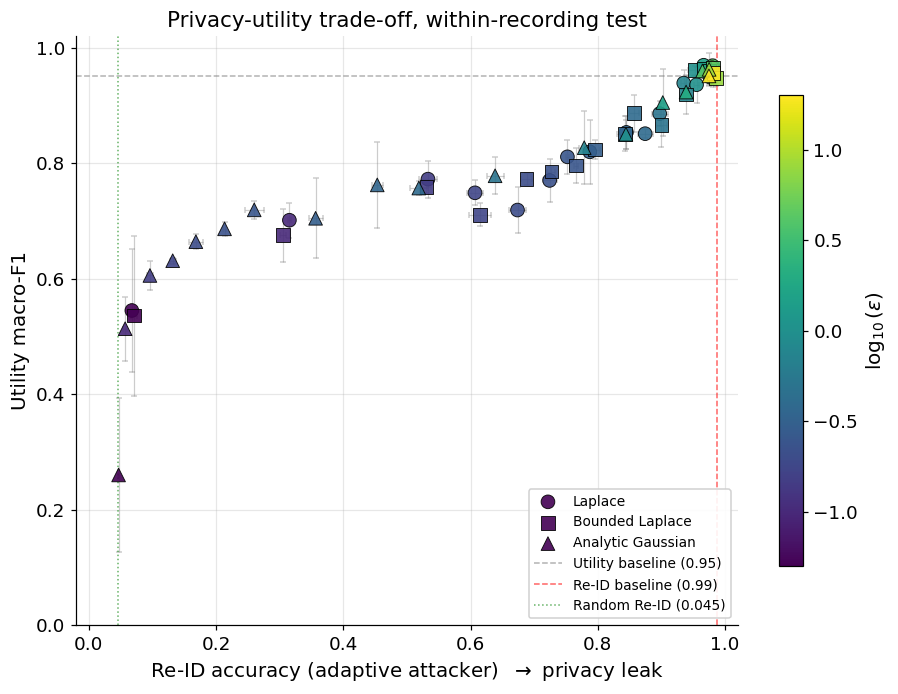

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))

eps_values = sorted(merged['eps'].unique())
log_eps_all = np.log10(np.array(eps_values))
norm = plt.Normalize(vmin=log_eps_all.min(), vmax=log_eps_all.max())
cmap = plt.cm.viridis

for mech in MECH_LABELS:
    sub = merged[merged['mechanism'] == mech]
    if sub.empty:
        continue
    colors = cmap(norm(np.log10(sub['eps'].values)))
    # Error bars (Re-ID x, Util y), one per config
    for _, row in sub.iterrows():
        ax.errorbar(
            row['reid_mean'], row['util_mean'],
            xerr=row['reid_std'] if not np.isnan(row['reid_std']) else 0,
            yerr=row['util_std'] if not np.isnan(row['util_std']) else 0,
            fmt='none', ecolor='gray', alpha=0.4, capsize=2, linewidth=0.8,
            zorder=2,
        )
    ax.scatter(
        sub['reid_mean'], sub['util_mean'],
        c=colors, marker=MECH_MARKERS[mech], s=80, alpha=0.9,
        edgecolors='black', linewidth=0.6, zorder=3,
        label=MECH_LABELS[mech],
    )

# Baseline reference lines
if not np.isnan(util_baseline_macro):
    ax.axhline(util_baseline_macro, color='gray', linestyle='--', linewidth=1, alpha=0.6,
               label=f'Utility baseline ({util_baseline_macro:.2f})')
if not np.isnan(reid_baseline_acc):
    ax.axvline(reid_baseline_acc, color='red', linestyle='--', linewidth=1, alpha=0.6,
               label=f'Re-ID baseline ({reid_baseline_acc:.2f})')
if not np.isnan(reid_random):
    ax.axvline(reid_random, color='green', linestyle=':', linewidth=1, alpha=0.6,
               label=f'Random Re-ID ({reid_random:.3f})')

ax.set_xlabel(r'Re-ID accuracy (adaptive attacker)  $\rightarrow$ privacy leak')
ax.set_ylabel('Utility macro-F1')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.02)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label=r'$\log_{10}(\varepsilon)$', shrink=0.8)

ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_title('Privacy-utility trade-off, within-recording test')
fig.tight_layout()
fig.savefig(FIGURES / 'money_figure_utility_vs_reid.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'money_figure_utility_vs_reid.png', bbox_inches='tight')
plt.show()

## Side-by-side: Utility and Re-ID each vs epsilon

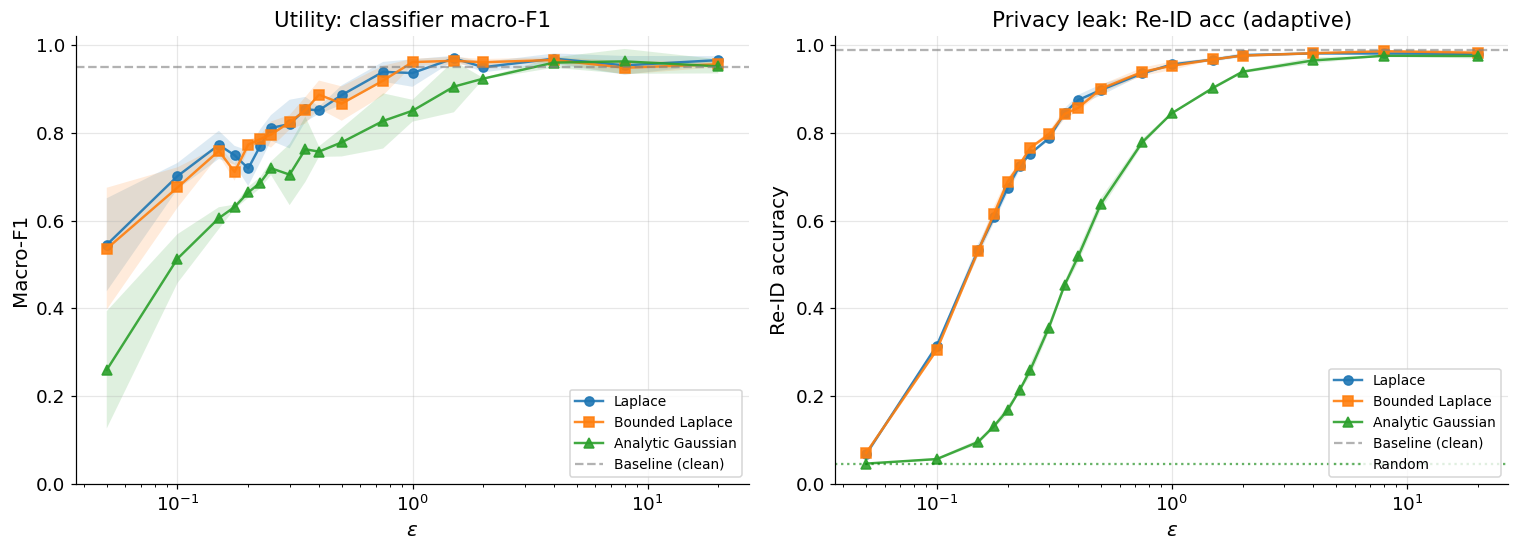

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)

for mech in MECH_LABELS:
    sub = merged[merged['mechanism'] == mech].sort_values('eps')
    if sub.empty:
        continue
    marker = MECH_MARKERS[mech]
    label = MECH_LABELS[mech]

    # Utility panel
    axes[0].plot(sub['eps'], sub['util_mean'], marker=marker, linestyle='-',
                 markersize=6, linewidth=1.6, label=label, alpha=0.9)
    axes[0].fill_between(sub['eps'],
                          sub['util_mean'] - sub['util_std'].fillna(0),
                          sub['util_mean'] + sub['util_std'].fillna(0),
                          alpha=0.15)

    # Re-ID panel
    axes[1].plot(sub['eps'], sub['reid_mean'], marker=marker, linestyle='-',
                 markersize=6, linewidth=1.6, label=label, alpha=0.9)
    axes[1].fill_between(sub['eps'],
                          sub['reid_mean'] - sub['reid_std'].fillna(0),
                          sub['reid_mean'] + sub['reid_std'].fillna(0),
                          alpha=0.15)

if not np.isnan(util_baseline_macro):
    axes[0].axhline(util_baseline_macro, color='gray', linestyle='--', alpha=0.6,
                    label='Baseline (clean)')
if not np.isnan(reid_baseline_acc):
    axes[1].axhline(reid_baseline_acc, color='gray', linestyle='--', alpha=0.6,
                    label='Baseline (clean)')
if not np.isnan(reid_random):
    axes[1].axhline(reid_random, color='green', linestyle=':', alpha=0.6, label='Random')

for ax, title, ylab in zip(
    axes,
    ['Utility: classifier macro-F1', 'Privacy leak: Re-ID acc (adaptive)'],
    ['Macro-F1', 'Re-ID accuracy'],
):
    ax.set_xscale('log')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(0, 1.02)

fig.tight_layout()
fig.savefig(FIGURES / 'utility_and_reid_vs_epsilon.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'utility_and_reid_vs_epsilon.png', bbox_inches='tight')
plt.show()

## Threat-model comparison (clean vs adaptive attacker)

Only shown if both threat models were run.

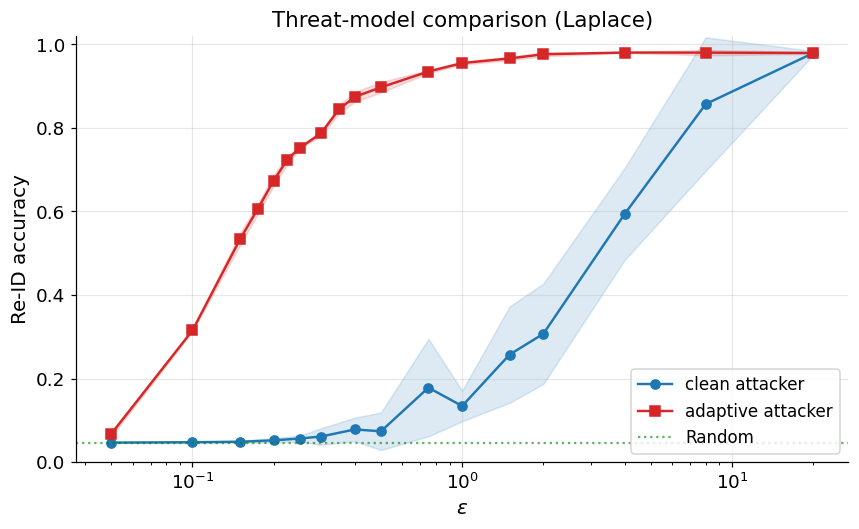

In [6]:
if 'clean_attacker' in reid_sweep['threat_model'].values:
    fig, ax = plt.subplots(figsize=(8, 5))
    for tmode, marker, color in [('clean_attacker', 'o', '#1f77b4'),
                                  ('adaptive_attacker', 's', '#d62728')]:
        sub = (
            reid_sweep[(reid_sweep['threat_model'] == tmode) &
                       (reid_sweep['mechanism'] == 'laplace')]
            .groupby('eps')['reid_accuracy'].agg(['mean', 'std']).reset_index()
        )
        if sub.empty:
            continue
        ax.plot(sub['eps'], sub['mean'], marker=marker, color=color,
                markersize=6, linewidth=1.6,
                label=tmode.replace('_', ' '))
        ax.fill_between(sub['eps'], sub['mean'] - sub['std'].fillna(0),
                         sub['mean'] + sub['std'].fillna(0),
                         alpha=0.15, color=color)
    if not np.isnan(reid_random):
        ax.axhline(reid_random, color='green', linestyle=':', alpha=0.6, label='Random')
    ax.set_xscale('log')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_ylabel('Re-ID accuracy')
    ax.set_title('Threat-model comparison (Laplace)')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.02)
    fig.tight_layout()
    fig.savefig(FIGURES / 'threat_model_comparison.pdf', bbox_inches='tight')
    plt.show()
else:
    print('Run train_reid.py with --threat-model both to enable this comparison.')

## Summary table and best operating points

In [7]:
summary = merged.copy()
summary['joint_score'] = summary['util_mean'] - summary['reid_mean']
summary.to_csv(RESULTS / 'privacy_utility_summary.csv', index=False)
print(f'Saved: {RESULTS / "privacy_utility_summary.csv"}')
print()
print('Best joint score (util_mean - reid_mean) per mechanism:')
for mech in MECH_LABELS:
    sub = summary[summary['mechanism'] == mech]
    if sub.empty:
        continue
    best = sub.loc[sub['joint_score'].idxmax()]
    print(f"  {mech:<20s}: eps={best['eps']:>6.3g}, joint={best['joint_score']:+.3f} "
          f"(util={best['util_mean']:.3f}+-{best['util_std']:.3f}, "
          f"reid={best['reid_mean']:.3f}+-{best['reid_std']:.3f})")

Saved: ../results/privacy_utility_summary.csv

Best joint score (util_mean - reid_mean) per mechanism:
  laplace             : eps=  0.05, joint=+0.477 (util=0.545+-0.106, reid=0.068+-0.006)
  laplace_bounded     : eps=  0.05, joint=+0.465 (util=0.536+-0.139, reid=0.071+-0.005)
  gaussian_analytic   : eps=  0.15, joint=+0.510 (util=0.606+-0.025, reid=0.096+-0.005)
